# EDA and Charts
This notebook focuses on the analysis of the final dataset, specifically on explaining outliers, on displaying charts, and on setting up the downstream operation of data visualization.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the dataframe
path = Path("../data/2_final.csv")
df = pd.read_csv(path,
    dtype={"REF_AREA": str, "PROVINCE": str},
    keep_default_na=False # This is to prevent automatic conversion of None and NA into empty fields
)

print("Dataframe loaded.")

Dataframe loaded.


## STEP 1. Descriptive analysis
In order to better understand the dataset, it's udeful to evaluate the basic characteristic of the data.

In [2]:
cols = ["ACCIDENTS", "INJURIES", "DEATHS"]

desc_df = pd.DataFrame({
    "Mean": df[cols].mean(),
    "Median": df[cols].median(),
    "Standard Dev": df[cols].std(),
    "IQR": df[cols].quantile(0.75) - df[cols].quantile(0.25),
    "Skewness": df[cols].skew(),
    "Kurtosis": df[cols].kurt()
}).round(2)

display(desc_df)

,Mean,Median,Standard Dev,IQR,Skewness,Kurtosis
ACCIDENTS,24.63,3.0,257.89,11.0,53.90,3619.19
INJURIES,34.55,5.0,338.58,18.0,53.06,3539.91
DEATHS,0.52,0.0,2.78,0.0,51.81,4391.08


The mean for accidents and injuries is much higher than the median, which proves that most municipalities experience a relatively low number of crashes every year, but a small group of big metropolitan cities pull the national average upward.

The high curtosis values and large standard deviation indicate a distribution with a heavy tail, meaning that there are extreme values caused by large metropolitan hubs.

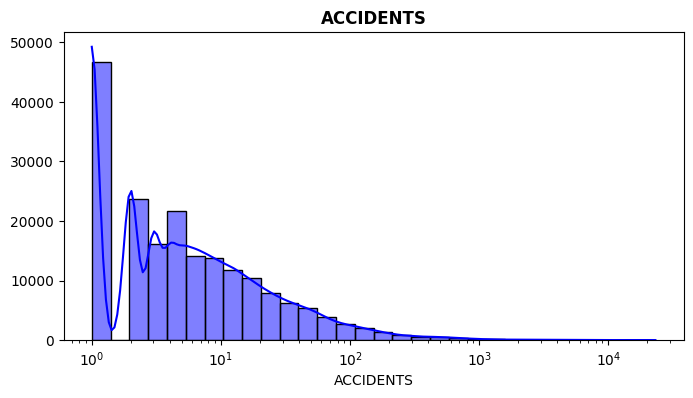

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["ACCIDENTS"] + 1, kde=True, color="#0000ff", bins=30, log_scale=True)
ax.set_title("ACCIDENTS", fontweight='bold')
ax.set_xlabel("ACCIDENTS")
ax.set_ylabel("")
plt.show()


The accidents distribution histogram displays a noticeable right-skew and a heavy tail, meaning that the vast majority of Italian municipalities record low annual collision numbers, while a small group of bigger metropolitan cities experience thousands of crashes.

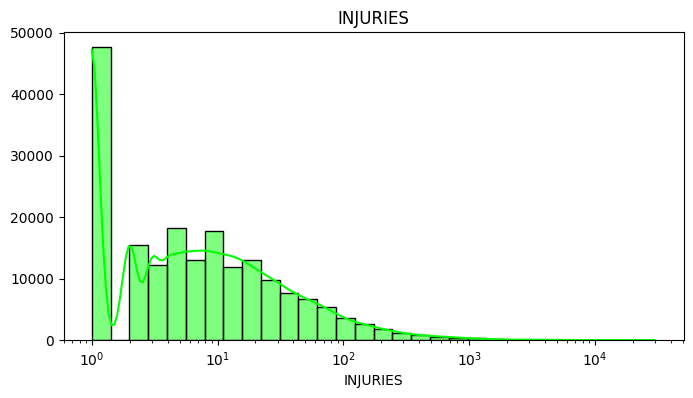

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["INJURIES"] + 1, kde=True, color="#00ff00", bins=30, log_scale=True)
ax.set_title("INJURIES")
ax.set_xlabel("INJURIES")
ax.set_ylabel("")
plt.show()

Similarly to the accident collision histogram, the injury distribution histogram follows the same right-skewed pattern: this confirms that accidents and injuries share a direct relationship (the more crashes, the more injured people), although bigger urban centers experience a higher number of collisions and relative injuries.

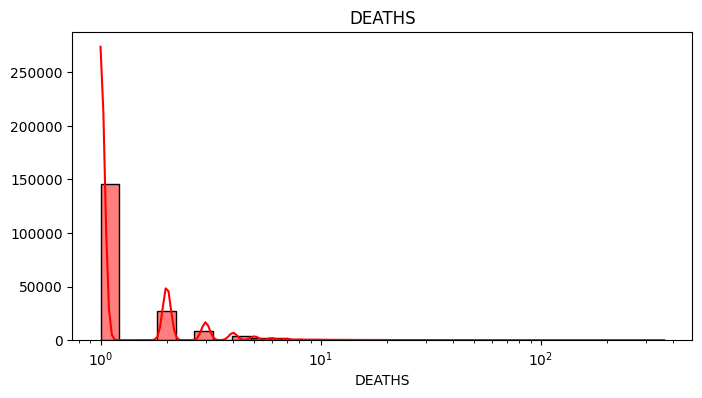

In [5]:

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["DEATHS"] + 1, kde=True, color="#ff0000", bins=30, log_scale=True)
ax.set_title("DEATHS")
ax.set_xlabel("DEATHS")
ax.set_ylabel("")
plt.show()

The deaths distribution plot, on the contrary, shows a higher clustering at lower values: this is because there are many municipalities with 0 or very few accidents, that on a logarithmic scale looks more stretched out than higher numbers (without the logarithmic scale, they would basically disappear).

## STEP 2. Temporal trends
After loading the final dataset, it's possible to analyse the multi-year trends across Italy for accidents, injuries, and deaths in order to identify macro-trends over the last decade.

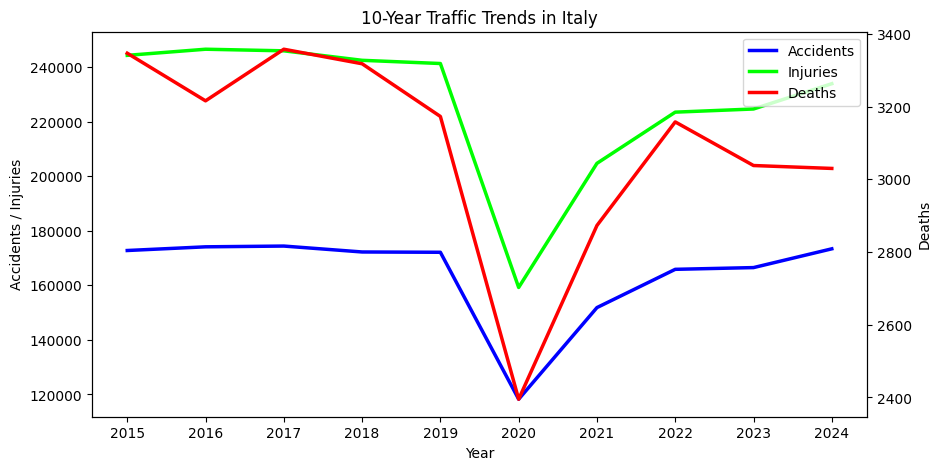

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Aggregate yearly totals across all municipalities for the last 10 years
yearly_trends = (
    df.groupby("TIME_PERIOD")[["ACCIDENTS", "INJURIES", "DEATHS"]].sum().reset_index().sort_values("TIME_PERIOD").tail(10)
)

# Plot the data
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Accidents & Injuries
ax1.plot(yearly_trends["TIME_PERIOD"], yearly_trends["ACCIDENTS"], 
         color="#0000ff", linewidth=2.5, label="Accidents")
ax1.plot(yearly_trends["TIME_PERIOD"], yearly_trends["INJURIES"], 
         color="#00ff00", linewidth=2.5, label="Injuries")

ax1.set_xlabel("Year")
ax1.set_ylabel("Accidents / Injuries")
ax1.set_xticks(yearly_trends["TIME_PERIOD"])

# Secondary Axis: Deaths (scaled separately as the number is too small)
ax2 = ax1.twinx()
ax2.plot(yearly_trends["TIME_PERIOD"], yearly_trends["DEATHS"], 
         color="#ff0000", linewidth=2.5, label="Deaths")
ax2.set_ylabel("Deaths")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("10-Year Traffic Trends in Italy")
plt.show()

Across the 10-year span, accidents and injuries display an almost-parallel relationship, whereas the number of deaths is much more volatile.

By looking at the graph, it's impossible not to notice che drastic drop of accidents, deaths and injuries in 2020 and, albeit less noticeably, in 2021, followed by a return to normal counts in the following years. This drastic drop coincides with the 2020 COVID-19 lockdown, which created an artificial downward deviation due to nationwide mobility restrictions.

This means that including the raw 2020 data without adjustments might severely distort regression models and lead to inaccurate predictions; this means that 2020 data should be either excluded or estimated based on previous data, as it represents an anomaly.

## STEP 3. Handling distortion caused by population differences
When analyzing risk ratios per 1.000 inhabitants, comparing municipalities with different population sizes causes analytical distortion:
1. in smaller cities, a single major crash may increase the rate to extreme values (e.g. 15 accidents in a village of 300 inhabitants yields a rate of 50 accidents per 1.000$ inhabitants), which ranks these tiny cities higher in risk than metropolitan centers;
2. conversely, the higher number of residents in large metropolitan centers (like Rome and Milan) dilutes the pro capite rate despite having thousands of crashes.

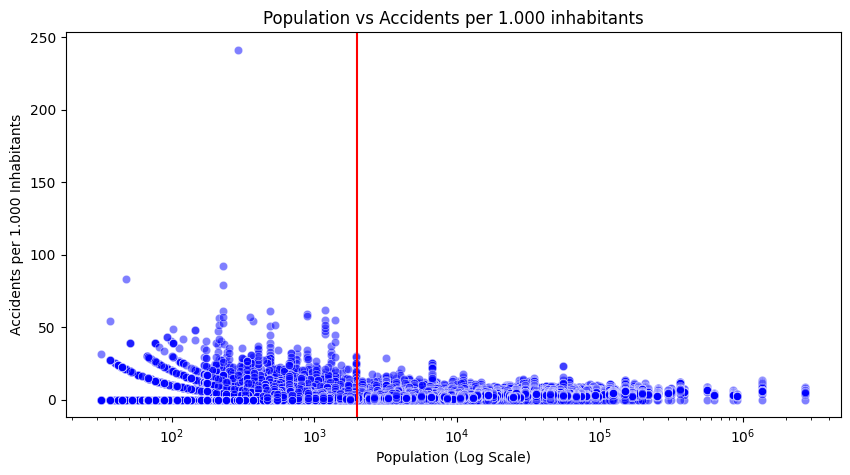

In [7]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df, 
    x="POPULATION", 
    y="ACCIDENTS_PER_1000_INH", 
    alpha=0.5, 
    color="#0000ff"
)

plt.xscale('log')
plt.axvline(x=2000, color="#ff0000")

plt.title("Population vs Accidents per 1.000 inhabitants")
plt.xlabel("Population (Log Scale)")
plt.ylabel("Accidents per 1.000 Inhabitants")
plt.show()

From the graph, it's clear that the data points for smaller cities are distributed more erratically across the vertical axis, especially for cities with less than  2.000 inhabitants (the red line), whereas for cities above 2.000 inhabitants the graph settles into a narrower horizontal distribution.

Since a single accident in a small town risks shifting the pro capite rate more dramatically than a single accident in a big city, including them in the data pool might corrupt the data with noise and yield analytical results that do not reflect the reality of traffic danger.

There is an abvious example of this: a data point in the upper left part of the graph, which seems to show a rate of around 250 incidents per 1.000 inhabitants in a city with a little more than 100 inhabitants.

In [8]:
outlier = df[(df['POPULATION'] < 1000) & (df['ACCIDENTS_PER_1000_INH'] > 200)]
display(outlier[['NAME', 'PROVINCE', 'POPULATION', 'ACCIDENTS', 'ACCIDENTS_PER_1000_INH', 'TIME_PERIOD']])

,NAME,PROVINCE,POPULATION,ACCIDENTS,ACCIDENTS_PER_1000_INH,TIME_PERIOD
39719,Albaredo per San Marco,SO,294,71,241.496599,2001


That data point represents Albaredo per San Marco (SO), which in 2001 experiences 71 accidents; due to the city having a low population (in 2024 it was less than 300 inhabitants, and presumably the 2001 population was also close to this number), this resulted in a rate of 241 accidents per 1.000 inhabitants.

A viable solution to avoind this kind of statistical phenomenon would be to apply a minimum population cutoff (e.g. only selecting cities with a minimum of 2.000 inhabitants) to reduce volatility in the data.

## PART 4. Structural outliers
Because the raw data measures the number of accidents, injuries and deaths per city, large cities willalways be at the top of the rankings because of their higher population and traffic. By normalizing the numbers with rates (per 1.000 inhabitants and per square km), we can level the playing field, comparing small towna with metropolitan cities more fairly.

In [9]:
def print_top10(df, col):
    # Order data by the column passed as argument and select first 10
    top10 = df.sort_values(by=col, ascending=False).head(10).copy()
    # Rename city column to show province
    top10["City"] = top10["NAME"] + " (" + top10["PROVINCE"] + ")"
    display_table = top10[["City", col, "POPULATION"]]
    display(display_table.reset_index(drop=True))

# Top 10 by accidents
print("Top 10 cities by accidents in 2024")
print_top10(df[df['TIME_PERIOD'] == 2024], "ACCIDENTS")

# Top 10 by injuries
print("Top 10 cities by injuries in 2024")
print_top10(df[df['TIME_PERIOD'] == 2024], "INJURIES")

# Top 10 by deaths
print("Top 10 cities by deaths in 2024")
print_top10(df[df['TIME_PERIOD'] == 2024], "DEATHS")

Top 10 cities by accidents in 2024


,City,ACCIDENTS,POPULATION
0,Roma (RM),13924,2747290
1,Milano (MI),7743,1365698
2,Genova (GE),3872,564080
3,Torino (TO),2968,853196
4,Napoli (NA),2544,909013
5,Firenze (FI),2291,361705
6,Palermo (PA),1987,628693
7,Bologna (BO),1946,390151
8,Bari (BA),1777,315831
9,Catania (CT),1459,298054


Top 10 cities by injuries in 2024


,City,INJURIES,POPULATION
0,Roma (RM),17196,2747290
1,Milano (MI),9585,1365698
2,Genova (GE),4594,564080
3,Torino (TO),4288,853196
4,Napoli (NA),3262,909013
5,Firenze (FI),2697,361705
6,Palermo (PA),2576,628693
7,Bari (BA),2528,315831
8,Bologna (BO),2439,390151
9,Catania (CT),2043,298054


Top 10 cities by deaths in 2024


,City,DEATHS,POPULATION
0,Roma (RM),134,2747290
1,Milano (MI),38,1365698
2,Napoli (NA),35,909013
3,Palermo (PA),22,628693
4,Ravenna (RA),17,156340
5,Torino (TO),16,853196
6,Perugia (PG),15,162050
7,Firenze (FI),14,361705
8,Ferrara (FE),13,129081
9,Verona (VR),13,255039


FOr example, by looking at raw numbers from 2024, the top 10 cities ranked by number of accidents, injuries and deaths are Rome, Milan, Naples and other big metropolitan centers, which is predictable: Rome has almost 3 million inhabitants, so it makes sense that it features the highest number of accidents, injuries and deaths, and not only in 2024.

In [12]:
def print_top10_rates(df, col, label_name):
    # Order data by the column passed as argument and select first 10 
    top10_all = df.sort_values(by=col, ascending=False).head(10).copy().reset_index(drop=True)
    # Do the same but filtering only vities with at least 2k inhabitants
    df_pop = df[df['POPULATION'] >= 2000]
    top10_pop = df_pop.sort_values(by=col, ascending=False).head(10).copy().reset_index(drop=True)
    # Rename city column to showprovince and population
    col_all = top10_all["NAME"] + " (" + top10_all["PROVINCE"] + "), pop: " + top10_all["POPULATION"].astype(str)
    col_filtered = top10_pop["NAME"] + " (" + top10_pop["PROVINCE"] + "), pop: " + top10_pop["POPULATION"].astype(str)
    comparison_table = pd.DataFrame({
        f"All Cities ({label_name})": col_all,
        f"Cities with >= 2k inhabitants ({label_name})": col_filtered
    })
    display(comparison_table)

# Top 10 by accidents
print("Top 10 cities by accidents per 1.000 inhabitants")
print_top10_rates(df[df['TIME_PERIOD'] == 2024], "ACCIDENTS_PER_1000_INH", "Accidents / 1k inh")

# Top 10 by injuries
print("Top 10 cities by injuries per 1.000 inhabitants")
print_top10_rates(df[df['TIME_PERIOD'] == 2024], "INJURIES_PER_1000_INH", "Injuries / 1k inh")

# Top 10 by deaths
print("Top 10 cities by deaths per 1.000 inhabitants")
print_top10_rates(df[df['TIME_PERIOD'] == 2024], "DEATHS_PER_1000_INH", "Deaths / 1k inh")

Top 10 cities by accidents per 1.000 inhabitants


,All Cities (Accidents / 1k inh),Cities with >= 2k inhabitants (Accidents / 1k inh)
0,"Argentera (CN), pop: 77","Forte dei Marmi (LU), pop: 6666"
1,"Colle Santa Lucia (BL), pop: 340","Bentivoglio (BO), pop: 5821"
2,"Montebruno (GE), pop: 201","Abbadia Lariana (LC), pop: 3164"
3,"Rocca Pia (AQ), pop: 169","Lignano Sabbiadoro (UD), pop: 6888"
4,"Paroldo (CN), pop: 186","Santa Margherita Ligure (GE), pop: 8323"
5,"Cervatto (VC), pop: 47","Solarolo (RA), pop: 4430"
6,"Belforte Monferrato (AL), pop: 492","Borghetto Santo Spirito (SV), pop: 4604"
7,"Anversa degli Abruzzi (AQ), pop: 300","Firenzuola (FI), pop: 4426"
8,"Bard (AO), pop: 102","Lavagna (GE), pop: 12367"
9,"Balmuccia (VC), pop: 113","Celle Ligure (SV), pop: 4795"


Top 10 cities by injuries per 1.000 inhabitants


,All Cities (Injuries / 1k inh),Cities with >= 2k inhabitants (Injuries / 1k inh)
0,"Argentera (CN), pop: 77","Forte dei Marmi (LU), pop: 6666"
1,"Colle Santa Lucia (BL), pop: 340","Mignano Monte Lungo (CE), pop: 2986"
2,"Balmuccia (VC), pop: 113","Baragiano (PZ), pop: 2469"
3,"Marmora (CN), pop: 58","Abbadia Lariana (LC), pop: 3164"
4,"Villarboit (VC), pop: 371","Bentivoglio (BO), pop: 5821"
5,"Paroldo (CN), pop: 186","Celle Ligure (SV), pop: 4795"
6,"Belforte Monferrato (AL), pop: 492","Solarolo (RA), pop: 4430"
7,"Brienno (CO), pop: 311","Assago (MI), pop: 9323"
8,"Carapelle Calvisio (AQ), pop: 70","Firenzuola (FI), pop: 4426"
9,"Piode (VC), pop: 187","Porto Cesareo (LE), pop: 6486"


Top 10 cities by deaths per 1.000 inhabitants


,All Cities (Deaths / 1k inh),Cities with >= 2k inhabitants (Deaths / 1k inh)
0,"Cervatto (VC), pop: 47","Paulilatino (OR), pop: 2086"
1,"Argentera (CN), pop: 77","Vezza d'Alba (CN), pop: 2373"
2,"Valloriate (CN), pop: 93","Porpetto (UD), pop: 2453"
3,"Montebruno (GE), pop: 201","Bolognetta (PA), pop: 4102"
4,"Campiglia Cervo (BI), pop: 499","Casola Valsenio (RA), pop: 2510"
5,"Perarolo di Cadore (BL), pop: 358","Suno (NO), pop: 2681"
6,"Cortanze (AT), pop: 256","Fonni (NU), pop: 3579"
7,"Derovere (CR), pop: 279","Mignano Monte Lungo (CE), pop: 2986"
8,"Vinadio (CN), pop: 574","Postiglione (SA), pop: 2011"
9,"Albaredo per San Marco (SO), pop: 294","San Costantino Calabro (VV), pop: 2025"


By adjusting numbers with rates, we get a clearer picture of the cities with the most accidents, injuries and deaths per 1.000 inhabitants. Since smaller cities tend to skew the data, as shown above, it's also useful to apply the filter and only select cities with at least 2.000 inhabitants.

## STEP 5. Spearman Correlation
A Spearman correlation matrix can help understand how the columns in the dataset are correlated, in order to spot any collinearities.

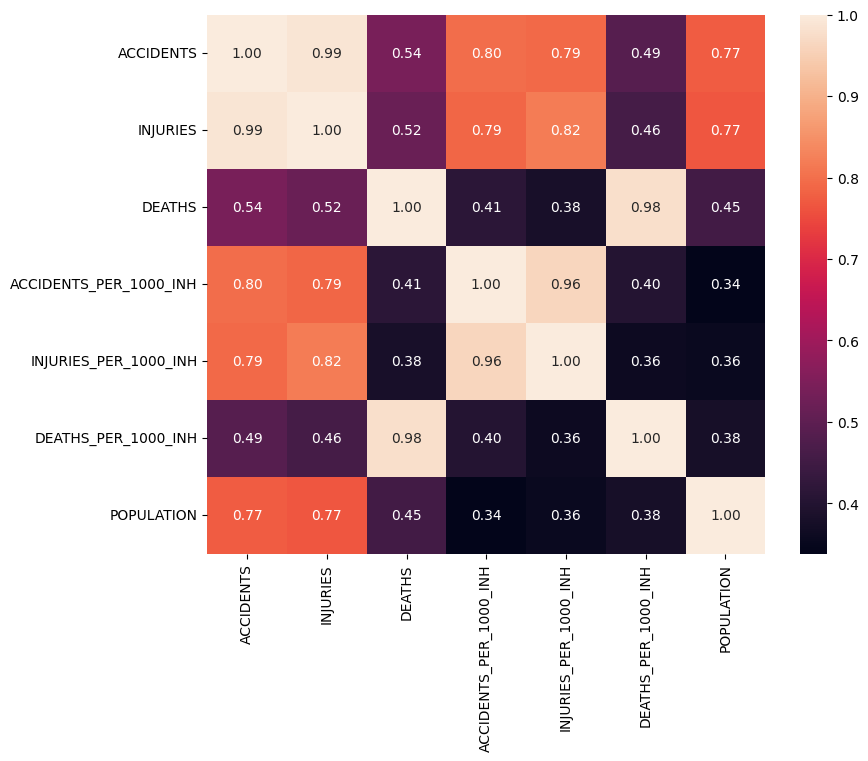

In [13]:
variables = ["ACCIDENTS", "INJURIES", "DEATHS", "ACCIDENTS_PER_1000_INH", "INJURIES_PER_1000_INH", "DEATHS_PER_1000_INH", "POPULATION"]
corr_matrix = df[variables].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f"
)

plt.show()

From the heatmap, it's obvious that there is an almost perfect monotonic correlation between accidents and injuries: this means that they substantially track the same phenomenon; thus, keeping both in the same model might imply severe multi-collinearity and redundancy.

Moreover, accidents and injuries as raw numbers show a strong positive correlation with population, whereas pro capite metrics (accidents and injuries per 1.000 inhabitants) show a lower correlation, meaning that they are less dependent on city size.

## STEP 5. Conclusions

From the above analysis, we can conclude that:

- the right-skew and high kurtosis in the metrics show that most municipalities experience low annual collisions, but a few large metropolitan centers drive national totals up;

- the normal trajectory of accidents and injuries was disrupted in 2020 by the pandemic-related drop, requiring the data of that years to be adjusted or excluded to prevent regression model distortion;

- procapite rates risk suffering distortion in tiny towns due to low populations, making a minimum population threshold necessary to eliminate statistical noise;

- raw metrics, not adjusted per inhabitants, naturally place bigger cities like Rome and Milan at the top of rankings, requiring normalized rates (per 1.000 inhabitants or square km) to fairly compare risk profiles across different city sizes;

- the correlation heatmap reveals an almost perfect monotonic relationship between accidents and injuries, meaning that one of the two variables should be dropped to eliminate multi-collinearity.